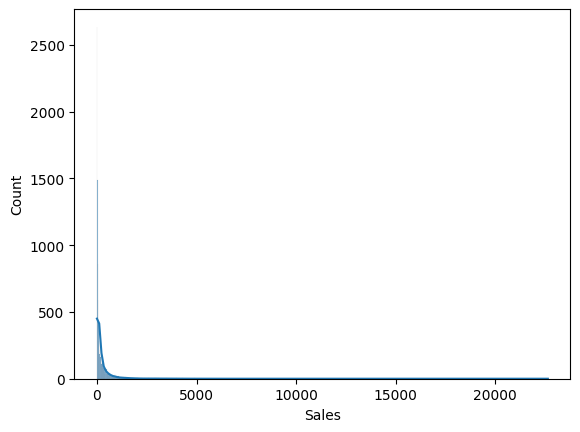

229.85800083049833
54.489999999999995


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("Sample - Superstore.csv", encoding = "cp1252")
df.head(5)
# task1
sns.histplot(data=df , x='Sales', kde=True)
plt.show()
mean_vlue=df['Sales'].mean()
median_value=df['Sales'].median()
print(mean_vlue)
print(median_value)

# it is right skewed and mean is more than median so there are many outliers


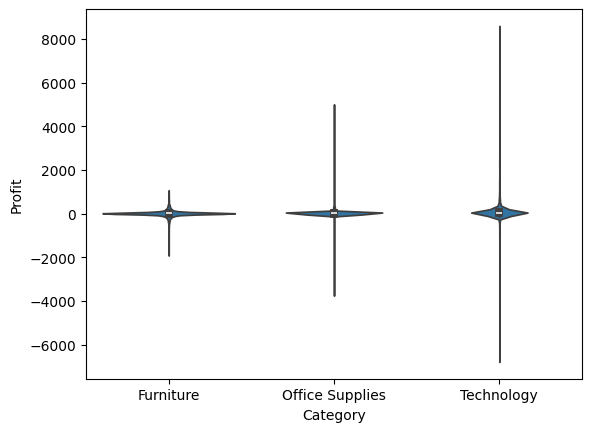

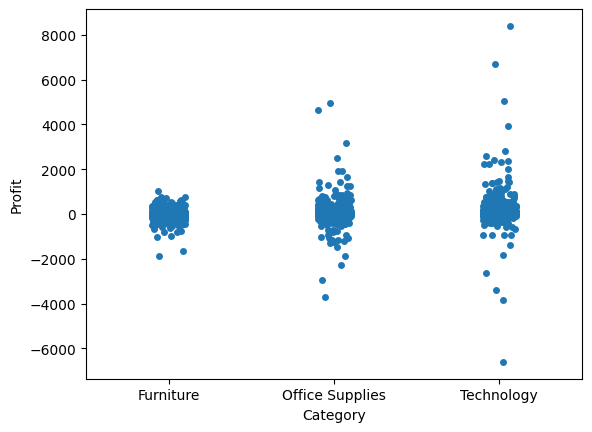

In [ ]:
#task2
sns.violinplot(data=df, x="Category", y="Profit")
plt.show()
sns.stripplot(data=df, x="Category", y="Profit")
plt.show()
#violin is better because it better shows data peaks and overall shape and density of data and jitterstrip can become crowded with many data points


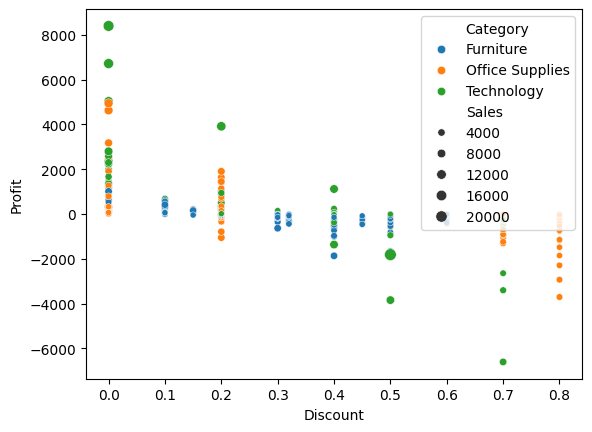

In [ ]:
#task3
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category", size="Sales")
plt.legend(loc="upper right")
plt.show()

#the more discount you give , the more loss there is in technology

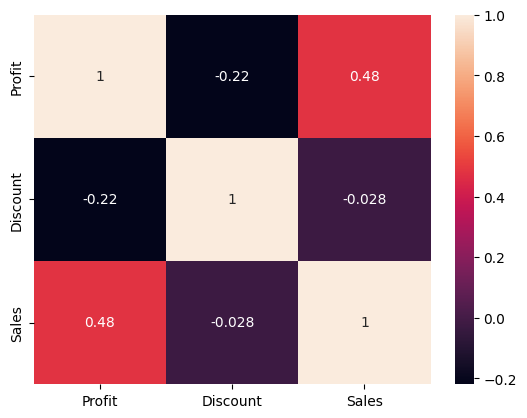

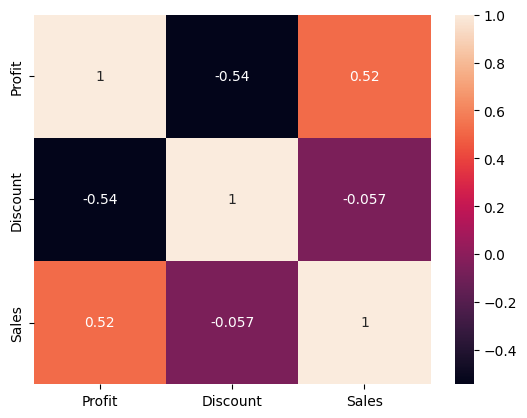

Difference between Pearson and Spearman:
            Profit  Discount     Sales
Profit    0.000000  0.323863  0.039342
Discount  0.323863  0.000000  0.028778
Sales     0.039342  0.028778  0.000000


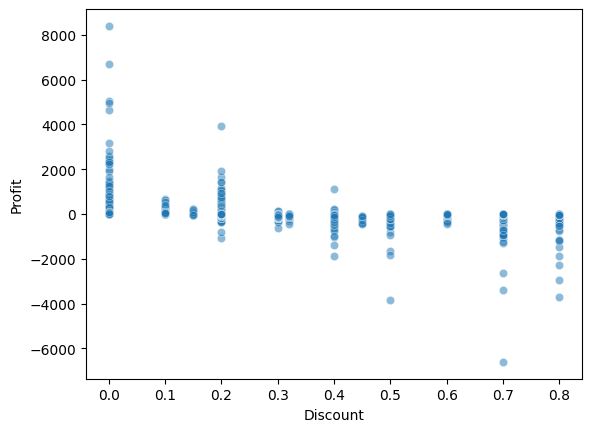

In [ ]:
#task4
#It tells you both the direction and strength of the relationship between two variables corr

nums=["Profit", "Discount", "Sales"]
pearson_matrix=df[nums].corr(method="pearson")
sns.heatmap(pearson_matrix, annot=True)
plt.show()

spearman_matrix=df[nums].corr(method="spearman")
sns.heatmap(spearman_matrix, annot=True)
plt.show()

difference = abs(pearson_matrix - spearman_matrix)
print("Difference between Pearson and Spearman:")
print(difference)

#Pearson measures linear correlation and affectected by ectreme values
#if Sales increases and Profit generally increases in a straightline pattern Pearson will be high and positive
#Spearman uses the rank/order of the values rather than their exact values
#useful when the relationship is consistently increasing/decreasing but isn't necessarily a straight line
#Correlation does not imply causation; a strong correlation between two variables does not prove that one variable causes the other

sns.scatterplot(data=df, x="Discount", y="Profit", alpha =0.5)
plt.show()
#higher discount gives lower profit neg corr

Category    Furniture  Office Supplies  Technology
Region                                            
Central   163797.1638       167026.415  170416.312
East      208291.2040       205516.055  264973.981
South     117298.6840       125651.313  148771.908
West      252612.7435       220853.249  251991.832


<Axes: xlabel='Category', ylabel='Region'>

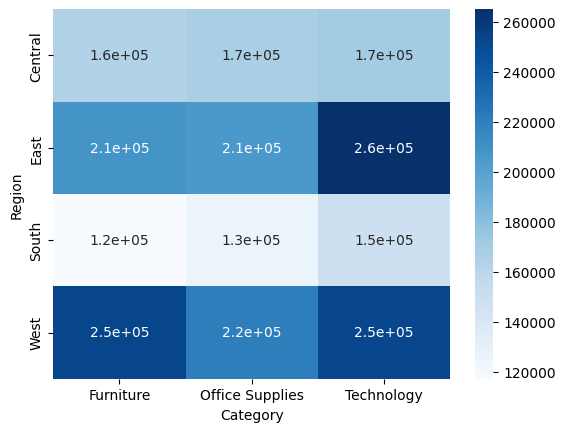

In [ ]:
#task5
pivot=pd.pivot_table(data=df, values ="Sales",index="Region", columns= "Category", aggfunc="sum")
print(pivot)
sns.heatmap(pivot, annot=True, cmap="Blues")
#eastXtechnology is largest

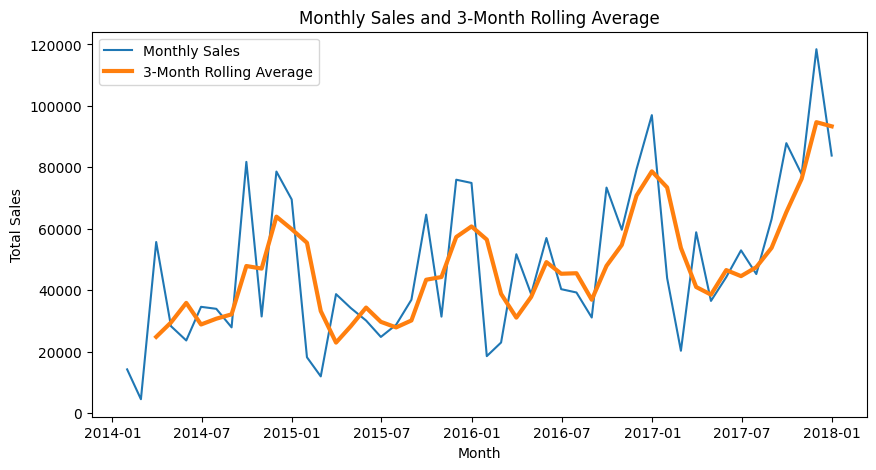

In [ ]:
#task6
#A 3 month rolling average takes the sales from 3 months and calculates their average
# order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df = df.set_index("Order Date") #making order date the index

monthly_sales = df["Sales"].resample("ME").sum()
rolling_avg = monthly_sales.rolling(3).mean()  #rolling avg

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales, label="Monthly Sales")
plt.plot(rolling_avg, label="3-Month Rolling Average", linewidth=3)

plt.title("Monthly Sales and 3-Month Rolling Average")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.show()
# it smooths out noise and make it visually easy to understand

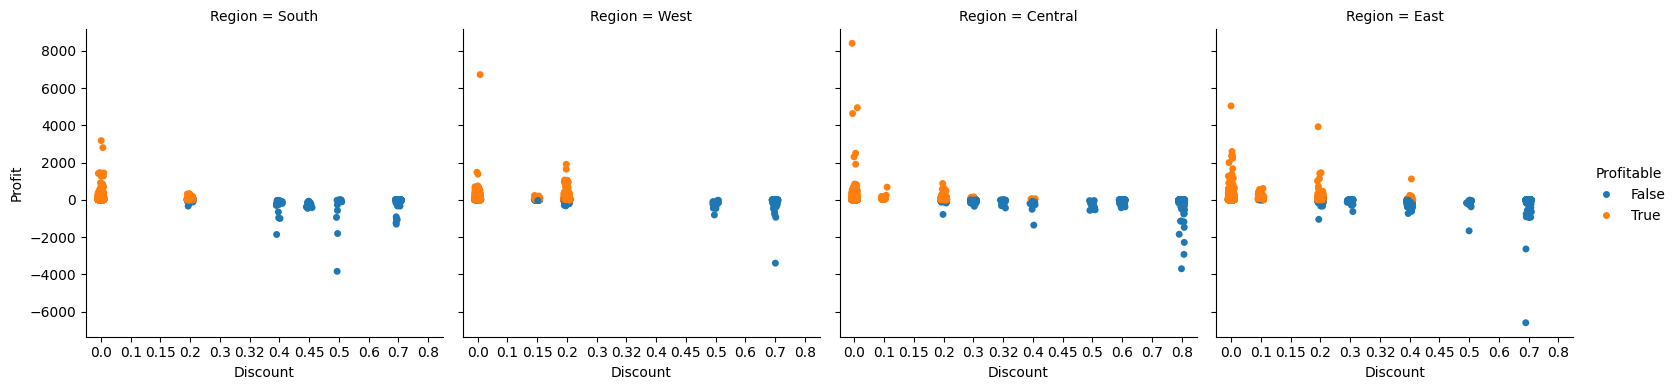

In [ ]:
#task7
df["Profitable"] = df["Profit"] > 0
sns.catplot(data=df,x="Discount",y="Profit",col="Region",hue="Profitable",kind="strip",jitter=True,height=4
)
plt.show()
#higher discounts give loss in the regions

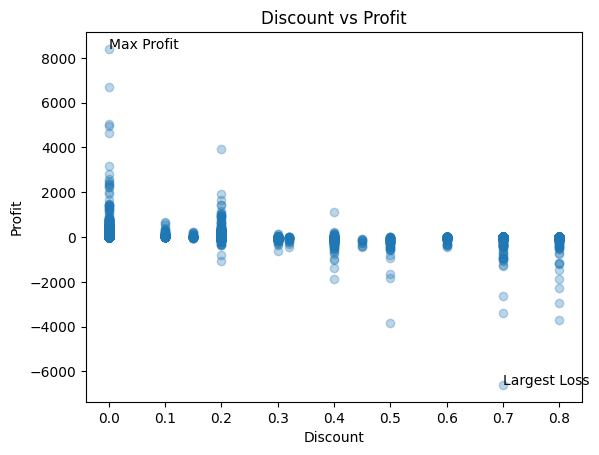

In [46]:

#task 8
x = df["Discount"].squeeze()
y = df["Profit"].squeeze()

plt.scatter(x, y, alpha=0.3)

i = y.argmax()
j = y.argmin()

plt.annotate("Max Profit", (x.iloc[i], y.iloc[i]))
plt.annotate("Largest Loss", (x.iloc[j], y.iloc[j]))

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()
